In [2]:
%load_ext autoreload
%autoreload 2

# Optional: import common packages
import numpy as np
import matplotlib.pyplot as plt
# x = [0,  1,    2]
# y = [0., 1, 0]
periodic = False


In [ ]:
# def parse_positions_line_by_line(filename):
#     """
#     Alternative method: parse line by line looking for x and y values
#     (Regex-free version)
#     """
#     x_coords = []
#     y_coords = []
#     current_x = None
#     current_y = None
#     last_x = None
#     last_y = None
    
#     try:
#         thresh = 0.1
#         with open(filename, 'r') as file:
#             for line_num, line in enumerate(file, 1):
#                 line = line.strip()
                
#                 # Look for x coordinate
#                 if line.startswith('x:'):
#                     try:
#                         # Split at the first colon, grab the second part, and convert to float
#                         current_x = float(line.split(':', 1)[1].strip())
#                     except ValueError:
#                         pass # Ignore if it can't be converted to a float
                
#                 # Look for y coordinate
#                 if line.startswith('y:'):
#                     try:
#                         current_y = float(line.split(':', 1)[1].strip())
#                     except ValueError:
#                         pass
                
#                 # If we have both x and y, save them
#                 if current_x is not None and current_y is not None:
                    
#                     # Filter out the (0.0, 0.0) origin points that cause the plotting glitch
#                     if abs(current_x) < 1e-6 and abs(current_y) < 1e-6:
#                         current_x = None
#                         current_y = None
#                         continue

#                     if(last_x is None or last_y is None or abs(last_x - current_x) > thresh or abs(last_y - current_y) > thresh):
#                         x_coords.append(current_x)
#                         y_coords.append(current_y)
#                         last_x = current_x
#                         last_y = current_y
#                         print(f"Position {len(x_coords)}: x={current_x}, y={current_y}")
#                         current_x = None
#                         current_y = None
                        
#                 # Reset on separator or new position block
#                 if line == '--' or line.startswith('position:'):
#                     current_x = None
#                     current_y = None
                    
#     except FileNotFoundError:
#         print(f"Error: File '{filename}' not found")
#         return [], []
#     except Exception as e:
#         print(f"Error reading file: {e}")
#         return [], []
    
#     return x_coords, y_coords

: 

In [3]:
# x, y = parse_positions_line_by_line("circle.txt")

# x = np.array(x)
# y = np.array(y)

# # Filter out points that are exactly (0, 0)
# # (Using a small tolerance is safer in case of floating point math)
# valid_mask = ~((np.abs(x) < 1e-6) & (np.abs(y) < 1e-6))
# # Create a mask that only keeps rows where X is NOT exactly zero
# valid_mask = (x != 0.0)

# # Apply the mask to both arrays
# x = x[valid_mask]
# y = y[valid_mask]

# print(x)


In [4]:
# x = [0, 1, 2, 3, 4, 5, 5.5, 5.5, 5.5, 5.5]
# y = [0, 0, 0, 0, 0, 0.5, 2, 3, 5, 6]
# x = [0, 1, 2, 3, 4, 5, 5.5, 5.5, 5.5, 5.5]
# y = [0, 0, 0, 0, 0, 0.5, 2, 3, 5, 6]
# print(len(x))
# print(len(y))

In [5]:
# x = [0, 1, 2, 3, 4]
# y = [0.5, 0.5, 0.5, 0.5, 0.5]
# print(len(x))
# print(len(y))

In [6]:
# x = [0,  1,    2,     3,    4,   4.5, 5, 4.5, 5.5, 6.25, 5.25, 4,3, 2,0]
# y = [0., 0.25, 0.25, 0.25, 0.25, -1,  -2, -4,  -5,  -4,    -2, 0, 0 ,0, 0]
# print(len(x))

In [7]:
from scipy.interpolate import splev, splprep

def generate_spline(x, y, wrap=False, plot_path=False, vel = 1.0):
    import matplotlib.pyplot as plt
    x = np.array(x)
    y = np.array(y)

    tck, u = splprep([x, y], s=0, per=wrap)

    u_fine = np.linspace(0, 1, 500)
    x_smooth, y_smooth = splev(u_fine, tck)

    dx_dt, dy_dt = splev(u_fine, tck, der=1)
    d2x_dt2, d2y_dt2 = splev(u_fine, tck, der=2)

    # Tangent angle at each point
    tangents = np.arctan2(dy_dt, dx_dt)

    curvature = np.abs(dx_dt * d2y_dt2 - dy_dt * d2x_dt2) / (dx_dt**2 + dy_dt**2)**1.5

    steering_angle_deg = np.degrees(curvature)

    angle_points = [0, 20, 40, 90]
    if(vel == 0):
        speed_points = [1.0, 1.0, 1.0, 1.0]
    else:
        speed_points = [vel, vel, vel, vel]
    speeds = np.interp(steering_angle_deg, angle_points, speed_points)

    velocity_multiplier = np.ones_like(u_fine)

    if not wrap:
        ramp_fraction = 0.2
        ramp_up_mask = u_fine < ramp_fraction
        velocity_multiplier[ramp_up_mask] = .25 + .75 * (1 - np.cos(np.pi * u_fine[ramp_up_mask] / ramp_fraction))

        ramp_fraction = 0.1
        ramp_down_mask = u_fine > (1 - ramp_fraction)
        velocity_multiplier[ramp_down_mask] = 0.5 * (1 + np.cos(np.pi * (u_fine[ramp_down_mask] - (1 - ramp_fraction)) / ramp_fraction))

    speeds_masked = speeds * velocity_multiplier

    if plot_path:
        # Evaluate derivatives at original waypoint parameters for tangents
        dx_orig, dy_orig = splev(u, tck, der=1)
        tangent_angles_orig = np.arctan2(dy_orig, dx_orig)
        arrow_scale = 0.1

        plt.figure(figsize=(5, 5))
        plt.plot(-y, x, 'o', label='Original points')
        plt.plot(-y_smooth, x_smooth, '-', label='Smooth spline')
        plt.quiver(
            -y, x,
            -np.sin(tangent_angles_orig), np.cos(tangent_angles_orig),
            scale=1/arrow_scale, scale_units='xy', angles='xy',
            color='lime', zorder=5, width=0.008,
            label='Tangents'
        )
        plt.legend()

        fig, ax1 = plt.subplots(figsize=(8, 4))

        ax1.plot(u_fine, speeds, 'b-', label='Speed (m/s)')
        ax1.set_xlabel('Spline parameter u')
        ax1.set_ylabel('Speed (m/s)', color='b')
        ax1.tick_params(axis='y', labelcolor='b')

        ax2 = ax1.twinx()
        ax2.plot(u_fine, curvature, 'r--', label='Curvature (1/m)')
        ax2.set_ylabel('Curvature (1/m)', color='r')
        ax2.tick_params(axis='y', labelcolor='r')

        ax3 = ax1.twinx()
        ax3.plot(u_fine, speeds_masked, 'black', label='Speed masked')
        ax3.set_ylabel('Speed masked', color='black')
        ax3.tick_params(axis='y', labelcolor='black')

        fig.suptitle('Speed and Curvature along the Path')
        fig.tight_layout()

        lines_1, labels_1 = ax1.get_legend_handles_labels()
        lines_2, labels_2 = ax2.get_legend_handles_labels()
        ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='best')

        plt.show()

    return x_smooth, y_smooth, speeds_masked, tangents


def save_track(x_smooth, y_smooth, speeds_masked, tangents, track_name="test"):
    my_dict = {
        "x": x_smooth,
        "y": y_smooth,
        "speed": speeds_masked,
        "theta": tangents
    }
    np.savez(f"../tracks/{track_name}.npz", **my_dict)

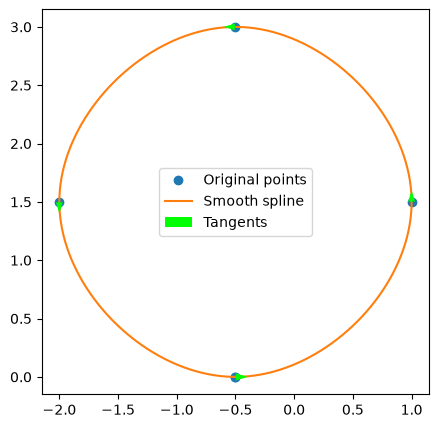

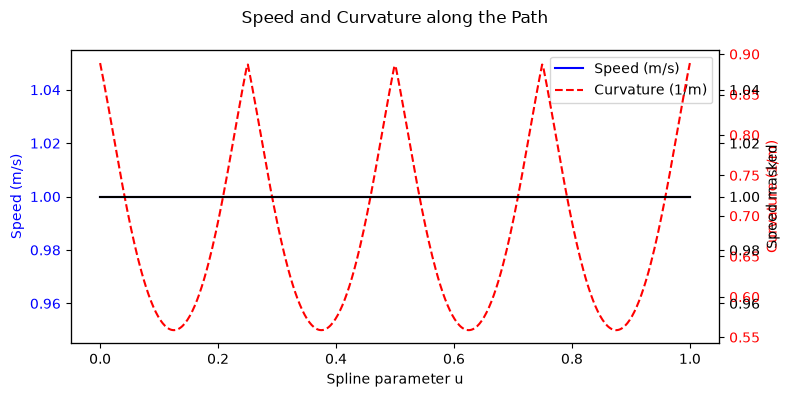

In [8]:
x = [0, 1.5, 3, 1.5, 0]
y = [0.5, -1, 0.5, 2.0, 0.5]
periodic = True
wrap = True
track_name = "blevel_circle"
#circle
x_smooth, y_smooth, speeds_masked, thetas = generate_spline(x, y, wrap = True, plot_path = True)
save_track(x_smooth, y_smooth, speeds_masked, thetas, track_name)

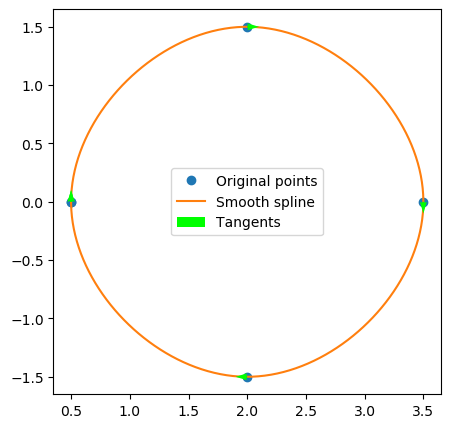

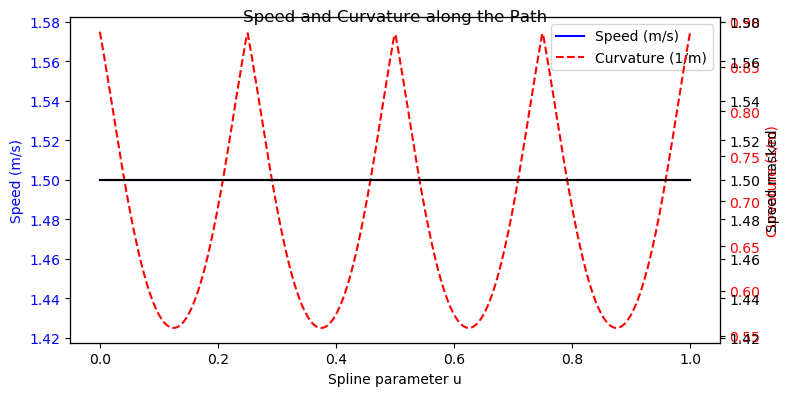

: 

In [ ]:
x = [0, 1.5, 0, -1.5, 0]
y = [-0.5, -2, -3.5, -2.0, -0.5]
periodic = True
wrap = True
track_name = "mocap_circle"
#circle
x_smooth, y_smooth, speeds_masked, thetas = generate_spline(x, y, wrap = True, plot_path = True, vel = 1.5)
save_track(x_smooth, y_smooth, speeds_masked, thetas, track_name)

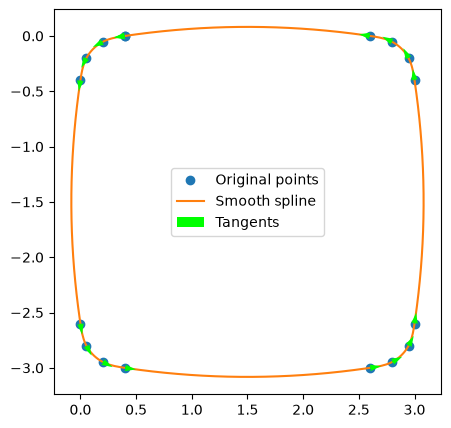

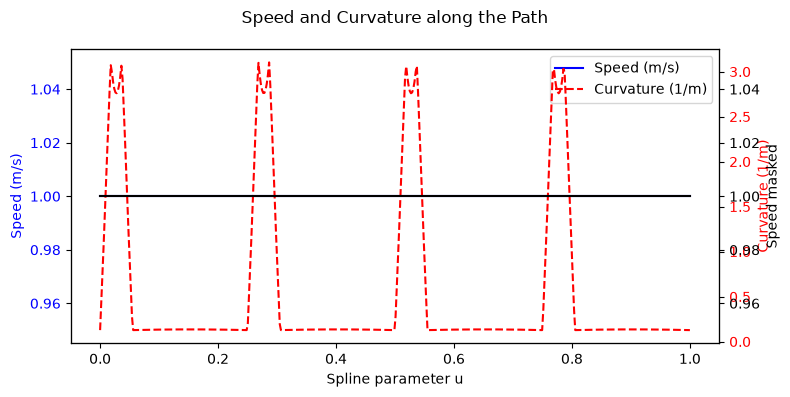

In [9]:
x = [0.0, -0.0536, -0.2, -0.4, -2.6, -2.8, -2.9464, -3.0,-3.0, -2.9464, -2.8, -2.6, -0.4, -0.2, -0.0536, 0.0, 0.0]
y = [-0.4, -0.2, -0.0536, 0.0, 0.0, -0.0536, -0.2, -0.4, -2.6, -2.8, -2.9464, -3.0, -3.0, -2.9464, -2.8, -2.6, -0.4]

periodic = False
wrap = True
track_name = "mocap_square3"
x_smooth, y_smooth, speeds_masked, thetas = generate_spline(x, y, wrap = True, plot_path = True)
save_track(x_smooth, y_smooth, speeds_masked, thetas, track_name)
# track oval

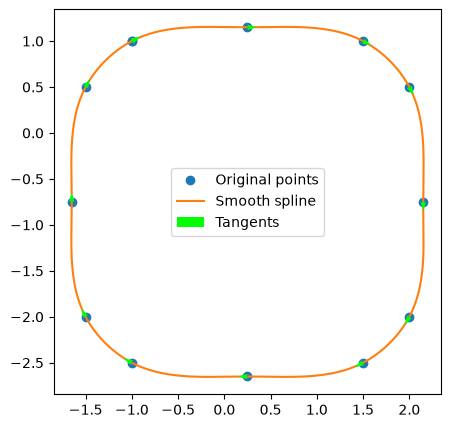

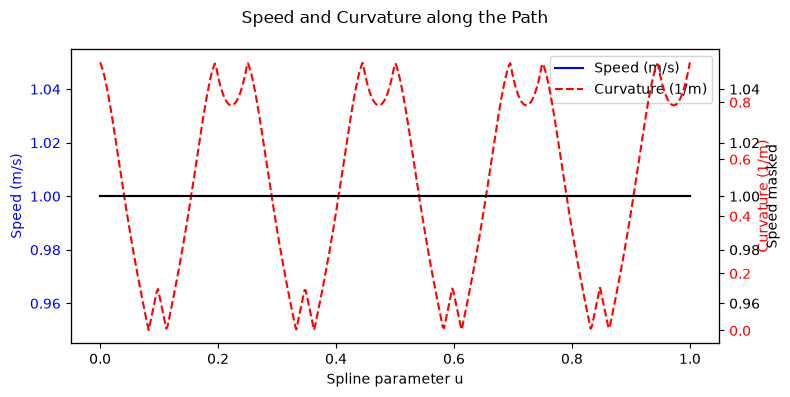

In [10]:
import numpy as np
x = [1,  1.15,   1,    0.5,-.75, -2,  -2.5,  -2.65, -2.5, -2, -.75, 0.5, 1]
y = [1, -.25, -1.5, -2, -2.15,   -2, -1.5,  -.25, 1.0,   1.5, 1.65, 1.5, 1]
periodic = False
wrap = True
track_name = "mocap_square2slow"
x_smooth, y_smooth, speeds_masked, thetas = generate_spline(x, y, wrap = True, plot_path = True, vel = 1.0)
save_track(x_smooth, y_smooth, speeds_masked, thetas, track_name)
# track oval

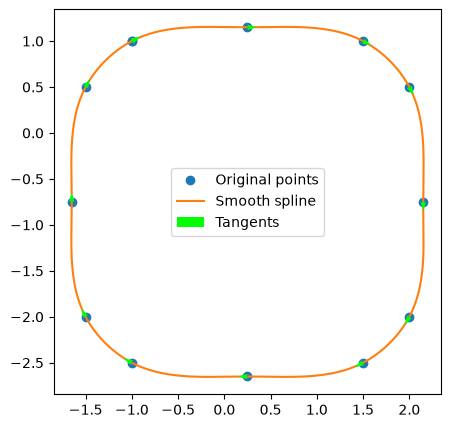

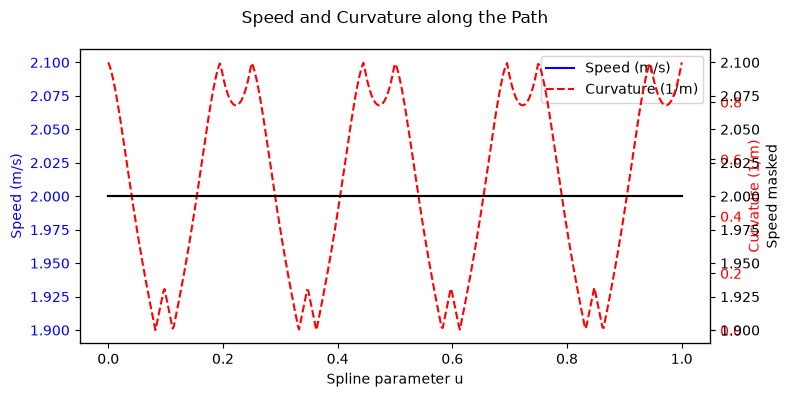

In [12]:
import numpy as np
x = [1,  1.15,   1,    0.5,-.75, -2,  -2.5,  -2.65, -2.5, -2, -.75, 0.5, 1]
y = [1, -.25, -1.5, -2, -2.15,   -2, -1.5,  -.25, 1.0,   1.5, 1.65, 1.5, 1]
periodic = False
wrap = True
track_name = "mocap_square2fast"
x_smooth, y_smooth, speeds_masked, thetas = generate_spline(x, y, wrap = True, plot_path = True, vel = 2.0)
save_track(x_smooth, y_smooth, speeds_masked, thetas, track_name)
# track oval

(500,)
(500,)
(500,)


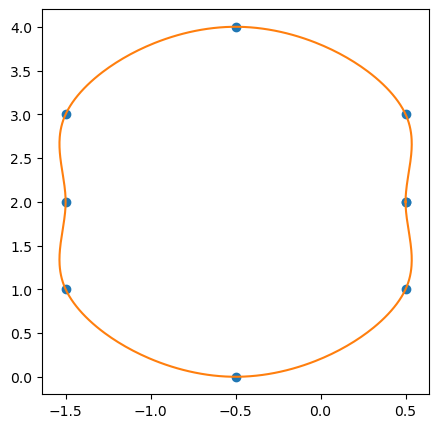

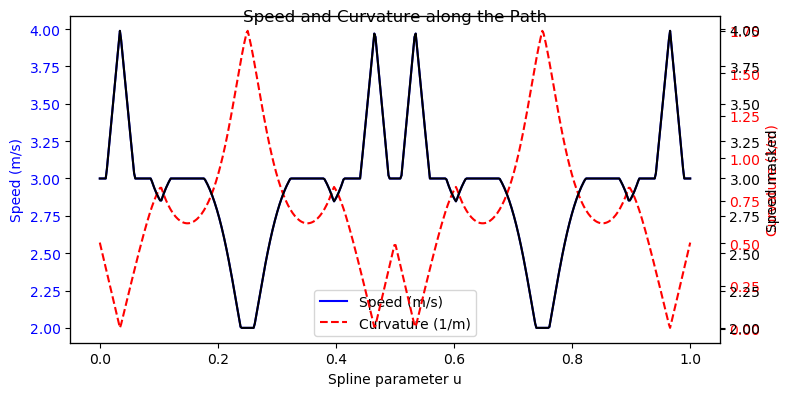

In [12]:
x = [2, 3, 4, 3, 2, 1, 0, 1, 2]
y = [-0.5, -0.5, 0.5, 1.5, 1.5, 1.5, 0.5, -0.5, -0.5]
periodic = True
wrap = True
track_name = "blevel_oval"
x_smooth, y_smooth, speeds_masked = generate_spline(x, y, wrap, plot_path = True)
save_track(x_smooth, y_smooth, speeds_masked, track_name)
# track oval

(500,)
(500,)
(500,)


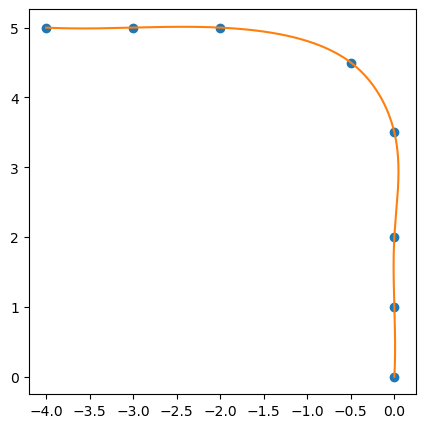

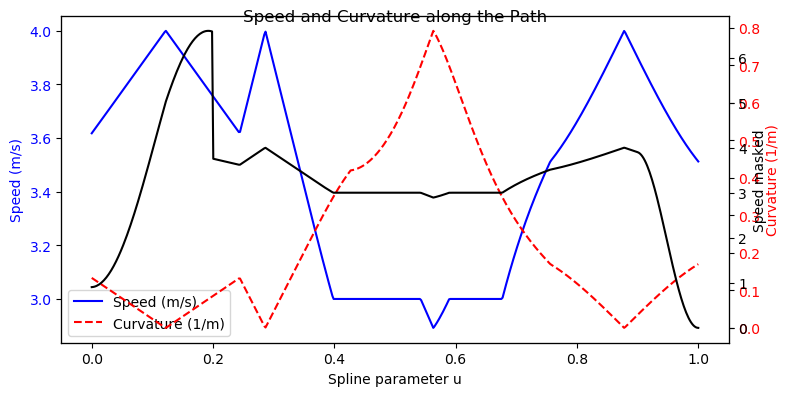

In [13]:
x = [0, 1, 2, 3.5, 4.5, 5, 5, 5]
y = [0, 0, 0, 0, 0.5, 2, 3, 4]
periodic = False
wrap = False
track_name = "blevel_turn"
x_smooth, y_smooth, speeds_masked = generate_spline(x, y, wrap, plot_path = True)
save_track(x_smooth, y_smooth, speeds_masked, track_name)
# turn

(500,)
(500,)
(500,)


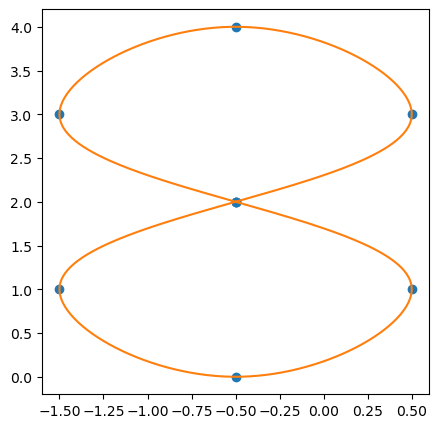

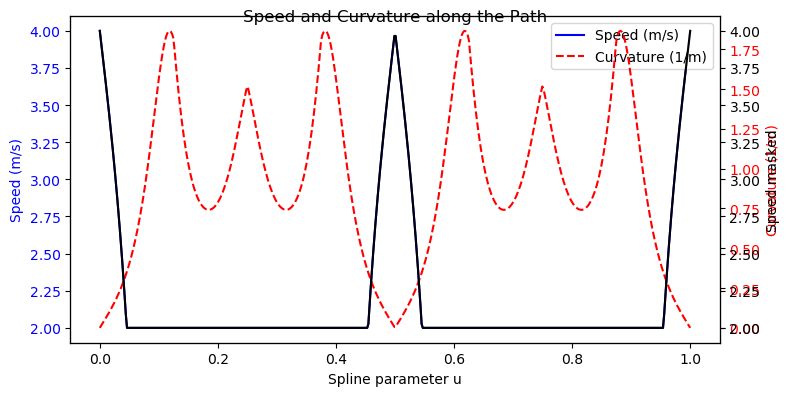

In [19]:
x = [2, 3, 4, 3, 2, 1, 0, 1, 2]
y = [0.5, -0.5, 0.5, 1.5,0.5, -0.5, 0.5, 1.5, 0.5]
periodic = True
wrap = True
track_name = "blevel_figure8"
x_smooth, y_smooth, speeds_masked = generate_spline(x, y, wrap, plot_path = True)
save_track(x_smooth, y_smooth, speeds_masked, track_name)
# turn

In [7]:
import math as ca



In [8]:
lf = 0.15875			# front tyres from center of gravity [m]
lr = 0.17145			# read tyres from center of gravity [m]
mass = 3.74 			# vehicle mass [kg]
Iz = 0.04712 			# moment of inertia [kgm^2]

p = [15.0, 15.0, 1.0, 1.0, 0.8, 0.8, 0.02, 0.001, 1.0, 0.05]
[-1.18283379e+01, 8.44133197e+00, -3.13430549e+00, 1.53994208e+00, 0.00000000e+00, 3.26238076e-01, 5.25505427e-03, 7.77642316e-02]
[-1.19038986e+01, 8.92304783e+00, -3.11663364e+00, 1.52242383e+00, -1.06785905e-02, 4.00329917e-01, -4.84997183e-01, 2.37764232e-01]
[-11.98117875, 9.40228659, -3.09298757, 1.48680442, -0.01992864, 0.55428524, -0.63623164, 0.39776423]
[-12.06018733, 9.87870879, -3.06122893, 1.44897618, -0.0364329, 0.7089282, -0.51780964, 0.4189]
[-12.14147115, 10.35216898, -3.02271471, 1.42140246, -0.06160558, 0.82595658, -0.19828905, 0.4189]
[-12.22599324, 10.82249848, -2.97905712, 1.41240511, -0.09298859, 0.91711507, 0.25768354, 0.4189]
[-12.31498457, 11.28944213, -2.93123241, 1.42714999, -0.12910757, 0.99421262, 0.7918575, 0.4189]
[-12.4098133, 11.75267232, -2.87973969, 1.46812999, -0.16941979, 1.0648714, 1.35421557, 0.4189]
[-12.5118703, 12.21180682, -2.82476705, 1.53559901, -0.21386682, 1.13409634, 1.90413766, 0.4189]
[-12.62247508, 12.66642565, -2.76629805, 1.62805282, -0.26260107, 1.20518069, 2.41090683, 0.4189]

[-12.62247508,
 12.66642565,
 -2.76629805,
 1.62805282,
 -0.26260107,
 1.20518069,
 2.41090683,
 0.4189]

In [37]:
# alphaf =  x[7] - ca.atan2(x[5] * lf + x[4], x[3])
# alphar =  ca.atan2(x[5] * lr - x[4], x[3])
# #arctan(omega * lr - vy, vx)



# Frx = mass * (x[6] * p[8]  -  p[9] * x[3]) - p[6] - p[7] * x[3] * x[3]
# Ffy = p[4] * ca.sin(p[2] * ca.atan(p[0] * alphaf))
# Fry = p[5] * ca.sin(p[3] * ca.atan(p[1] * alphar))

# dx0 = (x[3] * ca.cos(x[2])) - (x[4] * ca.sin(x[2])) #xdot
# dx1 = (x[3] * ca.sin(x[2])) + (x[4] * ca.cos(x[2])) #ydot
# dx2 = x[5] #phidot
# dx3 = (Frx - Ffy * ca.sin(x[7])) / mass + x[4] * x[5] #vxdot
# dx4 = (Fry + Ffy * ca.cos(x[7])) / mass - x[3] * x[5] #vydot
# dx5 = (lf * Ffy * ca.cos(x[7]) - lr * Fry) / Iz #omegadot

In [38]:
# print(alphaf, alphar, Frx, Ffy, Fry, dx0, dx1, dx2, dx3, dx4, dx5)

In [ ]:
# (x[5] * lf + x[4])/x[3]

0.04577881322817161